# PS-S06E03: XGBoost

This notebook tackles the [**Playground Series – Season 6, Episode 3: Predict Customer Churn**](https://www.kaggle.com/competitions/playground-series-s6e3), a competition focused on predicting if a customer is likely to cancel their subscription, based on features describing the customer's demographics and services used by them.

## Introduction

**XGBoost** is highly effective at capturing non-linear relationships between physiological markers (like BMI and Blood Pressure) and the target. It handles missing values internally (if any exist) and includes regularization (L1/L2) to prevent overfitting on smaller datasets.
We will need to encode our categorical variables (One-Hot or Label Encoding) before feeding them into XGBoost, as it treats inputs as numerical matrices.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E03: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e03-eda).

In [1]:
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e03_feature_engineering import FeatureFactory
from ps_s06e03_model_visualizer import ModelVisualizer
from ps_s06e03_experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'Churn'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   0    Male              0     Yes        Yes      29          Yes   
1   1    Male              0     Yes        Yes      58          Yes   
2   2    Male              0     Yes         No      58          Yes   
3   3  Female              0      No         No       1          Yes   
4   4  Female              0      No         No       1          Yes   

  MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection  \
0            No             DSL            Yes           No              Yes   
1            No             DSL            Yes          Yes               No   
2           Yes     Fiber optic             No          Yes               No   
3            No     Fiber optic             No           No               No   
4            No     Fiber optic             No           No               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessB

In [4]:
test_df = helper.read_dataset('test')

TEST DATASET

       id  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  594194  Female              0     Yes         No      72          Yes   
1  594195  Female              0     Yes         No      71          Yes   
2  594196    Male              0      No         No      12          Yes   
3  594197    Male              0     Yes        Yes      71          Yes   
4  594198  Female              0      No         No      15          Yes   

  MultipleLines InternetService       OnlineSecurity         OnlineBackup  \
0           Yes     Fiber optic                  Yes                  Yes   
1            No              No  No internet service  No internet service   
2            No             DSL                  Yes                  Yes   
3           Yes             DSL                  Yes                   No   
4            No     Fiber optic                  Yes                   No   

      DeviceProtection          TechSupport          StreamingTV  

## Feature Engineering

In [5]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
        'drop_id',
        'encoding',
        'ratios',
        'interactions',
        'binning'
]

In [6]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 20
New Feature Count: 31
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0    Male              0     Yes        Yes      29          Yes   
1    Male              0     Yes        Yes      58          Yes   
2    Male              0     Yes         No      58          Yes   
3  Female              0      No         No       1          Yes   
4  Female              0      No         No       1          Yes   

  MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection  \
0            No             DSL            Yes           No              Yes   
1            No             DSL            Yes          Yes               No   
2           Yes     Fiber optic             No          Yes               No   
3            No     Fiber optic             No           No               No   
4            No     Fiber optic             No           No               No   

  TechSupport StreamingTV 

## Optional Recursive Feature Elimination and Optuna Training

If the `PERFORM_RFE` variable in cell 3 is set to True, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.  This step is performed on a temporary feature engineered dataset to determine the optimal set of features, which are used to filter the in-fold feature engineered dataset.  If the variable is set to False, all features are used in training.

If the `PERFORM_OPTUNA_TUNING` variable in cell 3 is set to True, an Optuna trial is performed to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

In [7]:
n_jobs = 1 if USE_GPU else -1

# Convert object columns to 'category' dtype
X_rfe = X.copy()

cat_cols = X_rfe.select_dtypes(include=['category']).columns.tolist()
for col in cat_cols:
    X_rfe[col] = X_rfe[col].cat.codes.astype('int16')

obj_cols = X_rfe.select_dtypes(include=['object']).columns.tolist()
for col in obj_cols:
    X_rfe[col] = X_rfe[col].astype('category').cat.codes.astype('int16')

if PERFORM_RFE:    
    # Suppress the specific XGBoost warning to clean up the output
    warnings.filterwarnings('ignore', category=UserWarning, module='xgboost.core')
    
    # Use a conservative estimator for selection
    # High depth, moderate learning rate to find signal quickly
    clf = xgb.XGBClassifier(
        n_estimators=1000, 
        learning_rate=0.05, 
        max_depth=6, 
        colsample_bytree=0.8,
        reg_alpha=0.1,
        tree_method='hist',
        enable_categorical=True,
        device='cpu',
        random_state=seed,
        n_jobs=n_jobs
    )

    # Use 'neg_root_mean_squared_error' for regression
    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=KFold(n_splits=5, shuffle=True, random_state=seed),
        scoring='neg_root_mean_squared_error', 
        min_features_to_select=15,
        n_jobs=n_jobs
    )

    print('Running Recursive Feature Elimination (this will take a few minutes)...')
    rfecv.fit(X_rfe, y)
    
    # Results
    print(f'Optimal number of features: {rfecv.n_features_}')
    
    # Plot Performance vs Number of Features
    # Note: usage of cv_results_ depends on sklearn version, this is for recent versions
    n_scores = len(rfecv.cv_results_['mean_test_score'])
    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross validation score (AUC)')
    plt.plot(
        range(10, 10 + n_scores),
        rfecv.cv_results_['mean_test_score']
    )
    plt.show()

    # Save the selected features for the next step
    optimal_cols = X_rfe.columns[rfecv.support_]
else:
    print('Using all columns as optimal features.')
    optimal_cols = X_rfe.columns
        
print('\nOptimal Features:')
print(optimal_cols.tolist())

Using all columns as optimal features.

Optimal Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Total_Addon_Services', 'Contract_Code', 'Avg_Cost_Per_Month_Tenure', 'Expected_Total', 'Charges_Gap', 'Cost_Per_Service', 'num_services', 'cost_per_service', 'charges_per_tenure', 'total_service_count', 'tenure_month_to_month', 'tenure_group']


In [8]:
def objective(trial):
    
    # Suggest Parameters
    param = {
        # Core Booster Params
        'n_estimators': 4000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'min_child_weight': trial.suggest_float('min_child_weight', 5.0, 100.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.8),
        
        # Regularization
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 50.0, log=True),  # L1
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 50.0, log=True), # L2
        'gamma': trial.suggest_float('gamma', 0.1, 10.0),
        
        # Tree Structure
        'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        
        # Boilerplate for Classification
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'gpu_hist' if USE_GPU else 'hist',
        'enable_categorical': True,
        'early_stopping_rounds': 50,
        'random_state': seed,
        'n_jobs': n_jobs
    }

    y_encoded = y.map({'No': 0, 'Yes': 1})
    
    # Ensure optimal_cols is a standard list for filtering
    cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols
    
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    cv_auc = []

    # Standard CV Loop
    for fold, (train_idx, val_idx) in enumerate(kf.split(training_df, y_encoded)):
        
        # Create Folds
        X_train_fold = training_df.iloc[train_idx]
        y_train_fold = y_encoded.iloc[train_idx]
        
        X_val_fold = training_df.iloc[val_idx]
        y_val_fold = y_encoded.iloc[val_idx]
        
        # Feature Engineering (Per fold to prevent leakage)
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        # Restrict to optimal column set
        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            if not final_cols:
                raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
            X_train_trans = X_train_trans[final_cols]
            X_val_trans   = X_val_trans[final_cols]
        
        # Guard: ensure no object dtypes slip through (XGB native-cat wants category)
        obj_cols = X_train_trans.select_dtypes(include=['object']).columns.tolist()
        for col in obj_cols:
            X_train_trans[col] = X_train_trans[col].astype('category')
            X_val_trans[col]   = X_val_trans[col].astype('category')

        # Create model (Classifier)
        model = xgb.XGBClassifier(**param)

        # Train the model
        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            verbose=False
        )
        
        # Predict
        val_prob = model.predict_proba(X_val_trans)[:, 1]
        
        # Score this fold
        fold_score = roc_auc_score(y_val_fold, val_prob)
        cv_auc.append(fold_score)

    # Return the average ROC AUC across all folds
    return np.mean(cv_auc)


In [9]:
if PERFORM_OPTUNA_TUNING:
    print('Starting XGBoost Optuna Optimization (ROC AUC)...')
    
    # Use MedianPruner for efficiency
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=10
    )
    
    study_xgb = optuna.create_study(
        direction='maximize',
        study_name='xgb_predict_customer_churn_optuna', 
        pruner=pruner
    )
    
    study_xgb.optimize(
        objective,
        n_trials=50,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )
    
    print('\nBest Trial:')
    print(f'   ROC AUC: {study_xgb.best_value:.5f}')
    print('   Params: ', study_xgb.best_params)
    
    xgb_best_params = study_xgb.best_params
else:
    xgb_best_params = {
        'learning_rate': 0.01746743009121628,
        'max_depth': 5,
        'min_child_weight': 10.652338988495762,
        'subsample': 0.7704665157186866,
        'colsample_bytree': 0.5943421993162367,
        'reg_alpha': 0.1044384038640137,
        'reg_lambda': 19.908036096734033,
        'gamma': 1.2293511476494043,
        'grow_policy': 'lossguide'
    }
    
    print('\nUsing earlier calculated params:')
    print('  Params: ', xgb_best_params)


[I 2026-03-31 11:38:34,064] A new study created in memory with name: xgb_predict_customer_churn_optuna


Starting XGBoost Optuna Optimization (ROC AUC)...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-31 11:39:27,821] Trial 0 finished with value: 0.9152583170288373 and parameters: {'learning_rate': 0.03950731503355024, 'max_depth': 4, 'min_child_weight': 14.840341927275807, 'subsample': 0.7588884965798626, 'colsample_bytree': 0.7492026683591894, 'reg_alpha': 0.04469853318131583, 'reg_lambda': 9.521273347102307, 'gamma': 7.23555389528883, 'grow_policy': 'depthwise'}. Best is trial 0 with value: 0.9152583170288373.
[I 2026-03-31 11:40:42,885] Trial 1 finished with value: 0.9155322566925538 and parameters: {'learning_rate': 0.019992333862966387, 'max_depth': 6, 'min_child_weight': 16.40552961388907, 'subsample': 0.859773405087026, 'colsample_bytree': 0.5879429934820687, 'reg_alpha': 7.702178502917753, 'reg_lambda': 1.143329646093549, 'gamma': 4.863284629508849, 'grow_policy': 'lossguide'}. Best is trial 1 with value: 0.9155322566925538.
[I 2026-03-31 11:42:59,983] Trial 2 finished with value: 0.9154423135553371 and parameters: {'learning_rate': 0.007474426913609043, 'max_dep

## Model Training

In [10]:
xgb_tuned_params = {
    **xgb_best_params, # Unpack Optuna best params
    'n_estimators': 8000,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_jobs': n_jobs,
    'random_state': seed,
    'enable_categorical': True,      # Native categorical support
    'early_stopping_rounds': 100,
    'tree_method': 'gpu_hist' if USE_GPU else 'hist',
}

print('Final XGBoost CV Training with OOF / Test probabilities')
print('=======================================================')
print('Parameters used for training:')
print(xgb_tuned_params)

# Ensure optimal_cols is a standard list
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

y_encoded = y.map({'No': 0, 'Yes': 1}).astype(np.int8)

# Initialize Standard K-Fold
n_folds = 5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_probs = np.zeros(len(y_encoded))
test_probs = np.zeros(len(test_df))

# Standard CV Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(training_df, y_encoded)):
    print(f'Starting processing of fold {fold+1}')

    # Create Folds
    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y_encoded.iloc[train_idx]
    
    X_val_fold = training_df.iloc[val_idx]
    y_val_fold = y_encoded.iloc[val_idx]
    
    # Feature Engineering
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    
    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)
    
    # Restrict to optimal column set
    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]
        X_test_trans  = X_test_trans[final_cols]

    # Guard: ensure no object dtypes slip through (XGB native-cat wants category)
    obj_cols = X_train_trans.select_dtypes(include=['object']).columns.tolist()
    for col in obj_cols:
        X_train_trans[col] = X_train_trans[col].astype('category')
        X_val_trans[col]   = X_val_trans[col].astype('category')
        X_test_trans[col]  = X_test_trans[col].astype('category')

    # Create model (Classifier)
    model = xgb.XGBClassifier(**xgb_tuned_params)
    
    # Train Model
    model.fit(
        X_train_trans, y_train_fold,
        # eval_set order: [train, validation] so we can track both
        eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
        verbose=500
    )
    
    # Store history
    eval_results.append(model.evals_result())
    models.append(model)
    
    # Predict OOF probabilities
    val_prob = model.predict_proba(X_val_trans)[:, 1]
    oof_probs[val_idx] = val_prob
    
    # Score this fold
    fold_auc = roc_auc_score(y_val_fold, val_prob)
    print(f'Fold {fold+1} ROC-AUC: {fold_auc:.5f} (best_iteration={model.best_iteration})')
    
    # Accumulate Test Probs
    test_prob_fold = model.predict_proba(X_test_trans)[:, 1]
    test_probs += test_prob_fold / n_folds

# Final Metric Calculation
overall_auc = roc_auc_score(y_encoded, oof_probs)
print(f"Overall CV ROC-AUC: {overall_auc:.5f}")

Final XGBoost CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.01746743009121628, 'max_depth': 5, 'min_child_weight': 10.652338988495762, 'subsample': 0.7704665157186866, 'colsample_bytree': 0.5943421993162367, 'reg_alpha': 0.1044384038640137, 'reg_lambda': 19.908036096734033, 'gamma': 1.2293511476494043, 'grow_policy': 'lossguide', 'n_estimators': 8000, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'n_jobs': 1, 'random_state': 10301, 'enable_categorical': True, 'early_stopping_rounds': 100, 'tree_method': 'gpu_hist'}
Starting processing of fold 1
[0]	validation_0-auc:0.90012	validation_1-auc:0.89990
[500]	validation_0-auc:0.91596	validation_1-auc:0.91446
[1000]	validation_0-auc:0.91793	validation_1-auc:0.91559
[1500]	validation_0-auc:0.91904	validation_1-auc:0.91599
[2000]	validation_0-auc:0.91985	validation_1-auc:0.91616
[2500]	validation_0-auc:0.92051	validation_1-auc:0.91623
[3000]	validation_0-auc:0.92108	validation_1-auc:0.91627


## Visualizing Model Performance
We use four key plots to diagnose the health of our classification model

### Learning Curves (Train vs. Validation AUC)
This plot tracks the **Area Under the ROC Curve (AUC)** for both the training set (Blue) and validation set (Red) over each boosting iteration.

* **What to look for:** You want the Validation (Red) curve to go **up** and flatten out at a high value (closer to 1.0).down and flatten out.
* **Overfitting:** If the Blue line keeps rising rapidly towards 1.0 but the Red line stops improving or starts dropping, the model is memorizing the training data instead of generalizing.
* **Underfitting:** If both lines remain low and flat, the model isn't learning enough complexity to distinguish between classes.
* **Ideal:** The Red line reaches a maximum high value and stays stable. The gap between the Blue (Train) and Red (Validation) curves should not be massive.

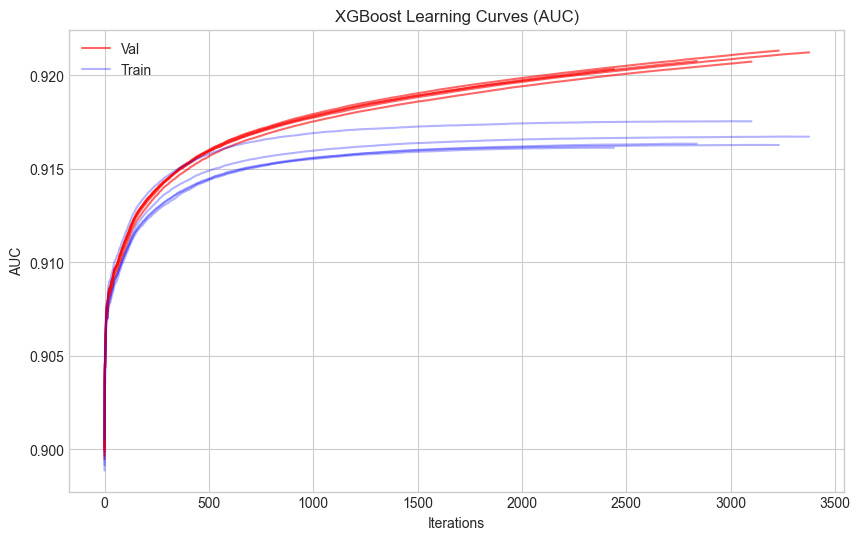

In [11]:
mviz = ModelVisualizer(model_name='XGBoost')

mviz.plot_learning_curves(eval_results, metric='auc')

### Feature Importance
This bar chart ranks which columns had the biggest impact on the model's predictions.
* **Validation Check:** Ensure the top features align with the high-signal columns identified in the EDA. For this dataset, `tenure` (the strongest numeric predictor) and `PaymentMethod` or `Contract` (the strongest categorical predictors) should likely be at the top.
* **Sanity Check:** If `id` or the original dataset's `customerID` appear in the top rankings, there is a data leakage problem. Additionally, ensure that `TotalCharges` is providing a legitimate signal and not just mirroring `MonthlyCharges` and `tenure` due to the cleaning process required for its formatting.
* **Engineering Check:** Look for the engineered features like `Total_Services` (service density) or financial ratios like `Charges_per_Tenure`. If these appear near the top, it confirms that capturing the cumulative impact of a customer's service profile added predictive power beyond the raw demographic data.

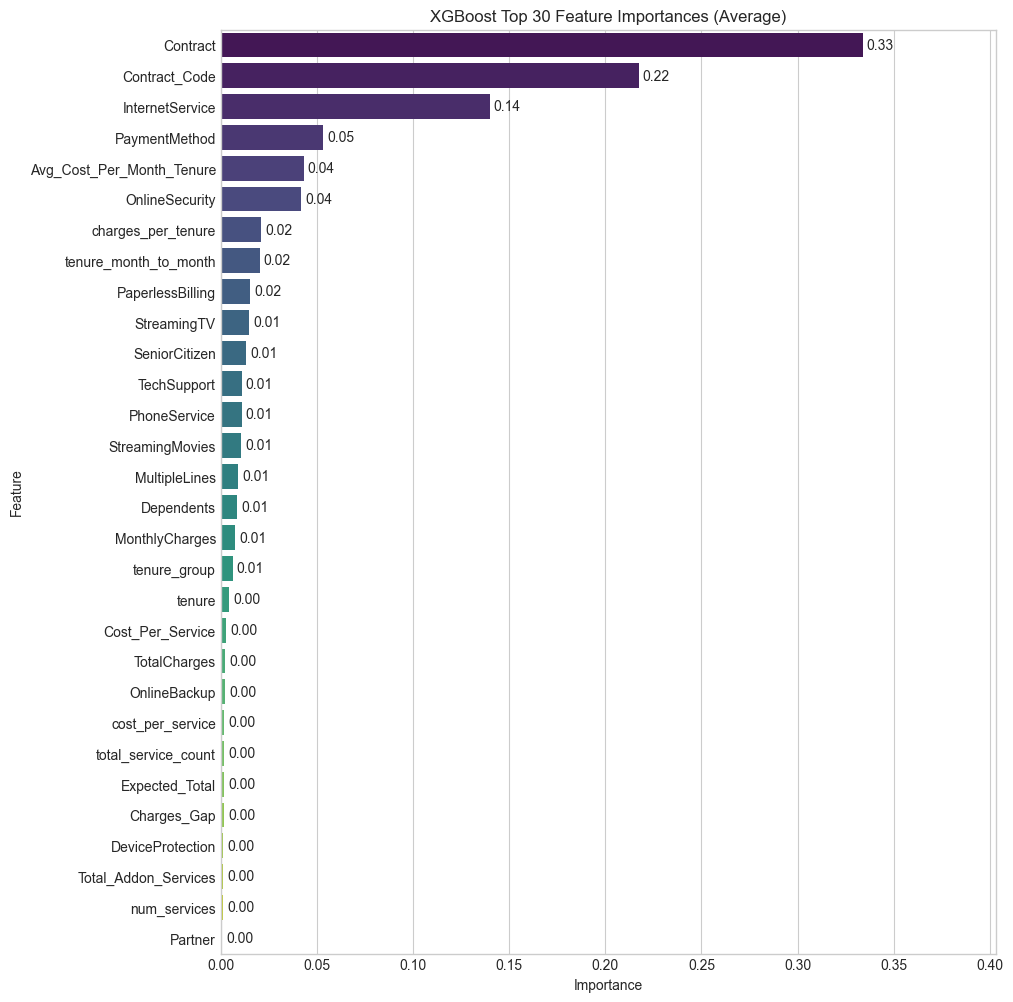

In [12]:
mviz.plot_feature_importance(models, show_values=True)

### Confusion Matrix
The **Confusion Matrix** provides a detailed breakdown of the model's performance by showing how many instances were correctly and incorrectly classified for each class.
* **True Negatives (Top-Left):** Customers who **do not** churn, and the model correctly predicted **No Churn**.
* **False Positives (Top-Right):** Customers who **do not** churn, but the model incorrectly predicted **Churn** (Type I Error).
* **False Negatives (Bottom-Left):** Customers who **do** churn, but the model incorrectly predicted **No Churn** (Type II Error). *In medical diagnostics, this is often the most critical error to minimize.*
* **True Positives (Bottom-Right):** Customers who **do** churn, and the model correctly predicted **Churn**.

Normalized confusion matrix


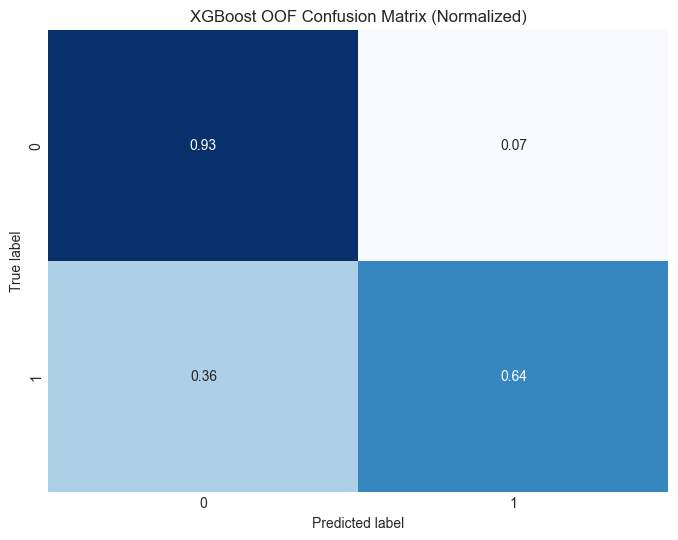

In [13]:
# Convert probabilities to hard classes (0 or 1) using a standard 0.5 threshold
y_pred_class = (oof_probs > 0.5).astype(int)

mviz.plot_confusion_matrix(y_encoded, y_pred_class, classes=[0, 1], normalize=True, title='XGBoost OOF Confusion Matrix (Normalized)')

### ROC Curve & AUC
The **Receiver Operating Characteristic (ROC)** curve illustrates the diagnostic ability of our binary classifier system as its discrimination threshold is varied.
* **The Plot:** It plots the **True Positive Rate (Sensitivity)** against the **False Positive Rate (1 - Specificity)**.
* **The Goal:** We want the blue line to hug the top-left corner as closely as possible, maximizing the area under it.
* **AUC Score:** The **Area Under the Curve (AUC)** summarizes the curve into a single number between 0.5 (random guessing) and 1.0 (perfect classification). This is the primary evaluation metric for this competition.

<Figure size 800x600 with 0 Axes>

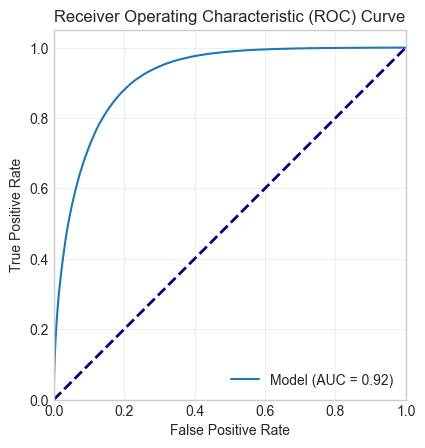

In [14]:
mviz.plot_roc_curve(y_encoded, oof_probs)

## Prepare Submission

In [15]:
submission_df = helper.read_dataset('submission')
submission_df[TARGET] = test_probs

print('SAMPLE SUBMISSION')
print('=================')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  Churn
0  594194  0.062
1  594195  0.001
2  594196  0.104
3  594197  0.003
4  594198  0.513
5  594199  0.160
6  594200  0.901
7  594201  0.002
8  594202  0.029
9  594203  0.322


In [16]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [17]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({
    'id': training_df['id'].values,
    'prob_xgb': oof_probs,
    'target': y_encoded.values
})
oof_df.to_csv(f'{output_dir}/xgb_oof_probs.csv', index=False)

test_pred_df = pd.DataFrame({
    'id': test_df['id'].values,
    'prob_xgb': test_probs
})
test_pred_df.to_csv(f'{output_dir}/xgb_test_probs.csv', index=False)

print(f'Saved for Blending: {output_dir}/xgb_oof_probs.csv, {output_dir}/xgb_test_probs.csv')

Saved for Blending: predictions/xgb_oof_probs.csv, predictions/xgb_test_probs.csv
